# Chapter 5: Case Study: Hacker Statistics

# Lesson 5.1: Random Numbers in Python
Randomness has many uses in science, art, statistics, cryptography, gaming, and other fields. In this section, we cover the `random` package, a sub-package of `numpy`, to generate random floats and integers.

## 1. Random Floats and Seeds
The `seed()` function sets the random seed, ensuring your results are reproducible between simulations. The `rand()` function generates a random float between zero and one.

### Exercise 1.1: Random float generation
* **Objective:** Use `seed()` to set a custom random seed and use `rand()` to generate a unique random decimal.


In [1]:
# Import numpy as np
import numpy as np

# Set the seed
np.random.seed(42)

# Generate and print a random float
random_val = np.random.rand()
print(random_val)


0.3745401188473625


## 2. Random Integers

The `randint()` function from the `random` package generates random integers within a specific range. The lower bound is inclusive, while the upper bound is exclusive.

### Exercise 1.2: Simulating custom random selection
* **Objective:** Use `randint()` to generate a random number between 1 and 10 to simulate choosing a specific item.


In [4]:
# Use randint() to simulate drawing an item between 1 and 10
item_number = np.random.randint(1, 11)
print(item_number)

# Use randint() again to simulate a second draw
second_item = np.random.randint(1, 11)
print(second_item)

8
5


## 3. Controlling Logic with Randomness

By combining random numbers with conditional `if-elif-else` statements, we can dynamically alter the path or variables of a program based on chance.

### Exercise 1.3: Determine game movement via random outcomes
* **Objective:** Use a random integer to determine whether a player moves forward, backward, or stands still based on specific logical thresholds.

In [12]:
# Initialize starting position
position = 20

# Roll a random number between 1 and 5
roll = np.random.randint(1, 6)

# Finish the control construct based on the roll outcome
if roll <= 2:
    position = position - 2
elif roll <= 4:
    position = position + 3
else:
    position = position + np.random.randint(1, 4)

print(roll)
print(position)


2
18



----
# Lesson 5.2: Random Walks in Python

A random walk is a mathematical object, known as a stochastic or random process, that describes a path consisting of a succession of random steps on some mathematical space. In data science, simulating random walks helps model continuous cumulative processes such as stock market fluctuations, particle diffusion, or gaming progressions.

## 1. Simulating a Random Walk

By utilizing a loop and tracking the cumulative sum of random steps, we can generate a coherent path where each step depends directly on the location established by the previous iteration.

### Exercise 2.1: Basic Random Walk Simulation
* **Objective:** Create a loop that simulates a 50-step random walk tracking a stock price movement, ensuring the progression is recorded inside a list.


In [13]:
# Set custom seed for reproducibility
np.random.seed(55)

# Initialize stock price starting at 100
stock_history = [100]

# Simulate 50 sequential steps
for x in range(50):
    # Fetch the last price in our history list
    current_price = stock_history[-1]
    
    # Generate a random price movement fluctuation (-2, -1, 0, 1, or 2)
    movement = np.random.randint(-2, 3)
    
    # Append the new updated price to our history list
    stock_history.append(current_price + movement)

print(stock_history)


[100, 100, 98, 99, 98, 96, 97, 99, 97, 96, 94, 95, 95, 96, 94, 95, 96, 96, 95, 93, 91, 89, 89, 91, 92, 93, 95, 94, 96, 94, 96, 98, 100, 99, 99, 98, 96, 96, 94, 95, 95, 93, 93, 91, 93, 93, 94, 92, 92, 92, 91]


## 2. Setting Boundaries and Visualizing the Path

In many real-world simulations, variables cannot drop below a certain baseline (e.g., prices cannot go below 0). We can enforce a minimum boundary using Python's built-in `max()` function, and then chart our random walk trajectory using `matplotlib`.

### Exercise 2.2: Constrained Simulation and Data Visualization
* **Objective:** Simulate a 100-step countdown walk that cannot drop below 0, then render a clean line plot to visualize the progression.


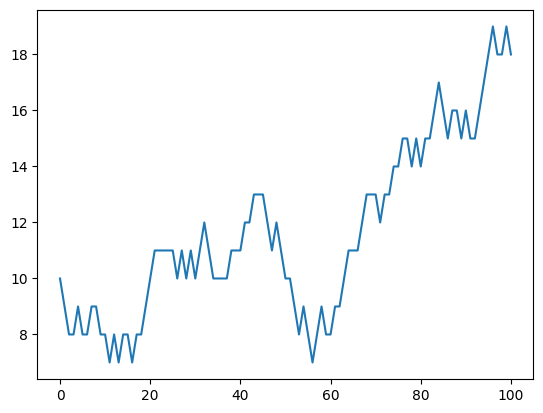

In [15]:
import matplotlib.pyplot as plt

# Set custom seed
np.random.seed(88)

# Initialize starting distance from destination
distance_walk = [10]

for x in range(100):
    step = distance_walk[-1]
    
    # Randomly step closer or stay still (-1, 0, or 1)
    change = np.random.randint(-1, 2)
    
    # Use max() to guarantee the distance never goes below 0
    next_step = max(0, step + change)
    distance_walk.append(next_step)

# Plotting the random walk path visually
plt.plot(distance_walk)
plt.show()


## 3. Probability Distributions

A single random walk only shows one possible outcome based on luck. To make a real statistical decision, we must simulate the random walk thousands of times (Hacker Statistics). By collecting the final endpoints of all these runs, we can create a histogram to see the distribution of probable outcomes.

### Exercise 3.1: Simulating Multiple Paths
* **Objective:** Loop a custom random walk 500 times, store the results in a list of lists, and use `np.transpose()` to restructure the data for correct plotting.

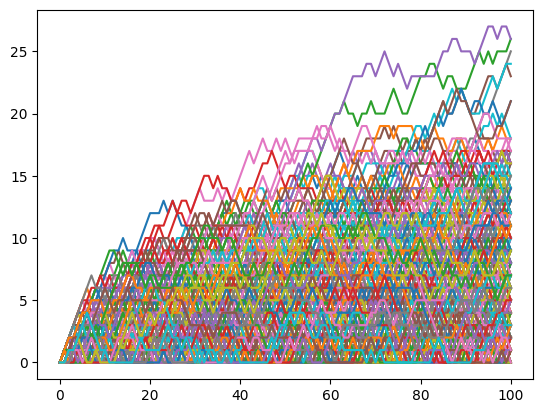

In [17]:
# Set custom seed
np.random.seed(7)

# Create a big container to hold all 500 simulations
all_simulations = []

# Loop 500 times to simulate 500 different games
for i in range(500):
    game_path = [0]  # Every game starts at position 0
    
    for x in range(100):
        current_spot = game_path[-1]
        step_change = np.random.randint(-1, 2)  # -1, 0, or 1
        
        # Keep boundary above 0
        next_spot = max(0, current_spot + step_change)
        game_path.append(next_spot)
        
    # Save this entire 100-step path into our big container
    all_simulations.append(game_path)

# Convert to numpy array and transpose so lines run correctly on the chart
np_sims_t = np.transpose(np.array(all_simulations))

# Plot all 500 paths together
plt.plot(np_sims_t)
plt.show()


## 4. Plotting the Final Histogram

To find the odds of winning or reaching a specific target, we extract only the very last value (endpoint) from each of the 500 simulated paths and plot them using a Histogram.

### Exercise 3.2: Extracting Endpoints and Calculating Odds
* **Objective:** Select the final row of the matrix, display its distribution with `plt.hist()`, and calculate the odds of finishing the game at a position greater than or equal to 5.


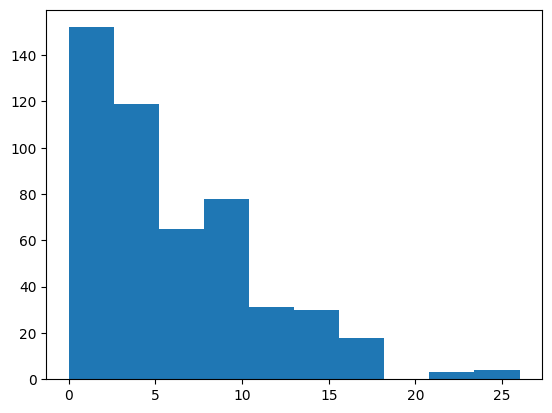

The calculated odds of winning are: 54.2 %


In [18]:
# Select the last row (the final position of all 500 runs)
final_positions = np_sims_t[-1, :]

# Build a histogram to see which final score happens the most
plt.hist(final_positions, bins=10)
plt.show()

# Calculate the exact odds of finishing at position 5 or higher
winning_odds = np.mean(final_positions >= 5) * 100
print("The calculated odds of winning are:", winning_odds, "%")
